# 2D FEM Solver Example from Lecture

For the general linear differential equation 

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

we aim to solve the following example:

\begin{equation}
-\frac{\partial}{\partial x}\left((y x+1) \frac{\partial \Phi}{\partial x}\right)-\frac{\partial}{\partial y}\left((x+y+1) \frac{\partial \Phi}{\partial y}\right)+2 x^2 \Phi=x+y^2
\end{equation}

\begin{equation}
G=\{(x, y) \mid 0<x<1 \wedge 0<y<0.7\}
\end{equation}

\begin{equation}
\left.\Phi\right|_{\partial G}=x^2+y
\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

sns.set_theme()

import functions as myfunc

## Define the given functions and parameters

In [2]:
def alpha1(x, y):
    return x * y + 1

def alpha2(x, y):
    return x + y + 1

def beta(x, y):
    return 2 * np.power(x, 2)

def rhs(x, y):
    return x + np.power(y, 2)

BOUNDARY_INDICES = np.array([0,4,3,5], dtype=int)  # ! order is important. Selected anticlockwise
def boundary_func(x, y):
    return np.power(x, 2) + y

DOMAIN_KNOTS = np.array([[1,0.7],[0.5,0.35],[0.5,0.18],[0,0],[0,0.7],[1,0]], dtype=float)   # (x1,y1), (x2,y2), ... 
ELEMENTS = np.array([[0,4,1],[3,1,4],[5,0,1],[3,5,2],[2,1,3],[5,1,2]], dtype=int)   # 

In [3]:
myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)

(<List of Lists sparse array of dtype 'float64'
 	with 28 stored elements and shape (6, 6)>,
 array([0.10477315, 0.13669219, 0.03015898, 0.03714044, 0.06588426,
        0.08075155]))

Triangle 0: [array([1. , 0.7]), array([0. , 0.7]), array([0.5 , 0.35])]
Triangle 1: [array([0., 0.]), array([0.5 , 0.35]), array([0. , 0.7])]
Triangle 2: [array([1., 0.]), array([1. , 0.7]), array([0.5 , 0.35])]
Triangle 3: [array([0., 0.]), array([1., 0.]), array([0.5 , 0.18])]
Triangle 4: [array([0.5 , 0.18]), array([0.5 , 0.35]), array([0., 0.])]
Triangle 5: [array([1., 0.]), array([0.5 , 0.35]), array([0.5 , 0.18])]


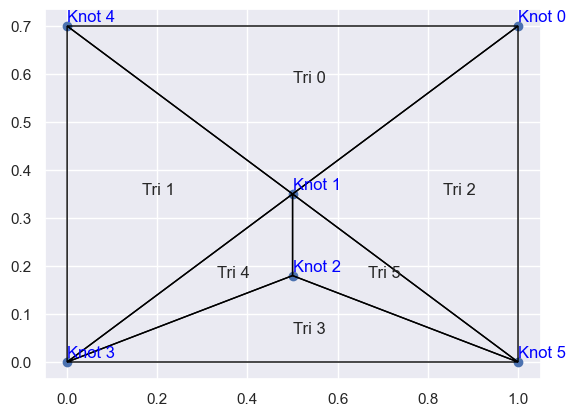

In [4]:
# Plot Domain Knots
TEXT_OFFSET = 0.01
plt.scatter(DOMAIN_KNOTS[:,0], DOMAIN_KNOTS[:,1])
for i, (x, y) in enumerate(DOMAIN_KNOTS):
    plt.text(x, y+TEXT_OFFSET, f"Knot {i}", color="blue", )

# Plot Triangles
for i, triangle in enumerate(ELEMENTS):
    triangle_coordinates = [DOMAIN_KNOTS[triangle[0]], DOMAIN_KNOTS[triangle[1]], DOMAIN_KNOTS[triangle[2]]]    # [[x1, y1], [x2, y2], [x3, y3]]
    print(f"Triangle {i}: {triangle_coordinates}")

    polygon = patches.Polygon(triangle_coordinates, closed=True, fill=False, edgecolor="black")
    plt.gca().add_patch(polygon)
    centroid = np.mean(triangle_coordinates, axis=0)    # x, y
    plt.text(centroid[0], centroid[1], f"Tri {i}")

plt.show()

## Form a Linear Equations System

\begin{equation}
\sum_j K_{k j} \Phi_j=D_k-\sum_d K_{k d} \Phi_d \quad \text { mit } \quad k, j=1 . . N_i
\end{equation}

\begin{equation}
\mathcal{K}_{l m}=\frac{1}{4 \Delta_E}\left[\alpha_1\left(x_M, y_M\right) b_l b_m+\alpha_2\left(x_M, y_M\right) c_l c_m\right]+\frac{\Delta_E}{12} \beta\left(x_M, y_M\right)\left(1+\delta_{l m}\right) \quad l, m=1 . .3
\end{equation}

\begin{equation}
\mathcal{D}_l=\frac{\Delta_E}{3} f\left(x_M, y_M\right)
\end{equation}

c:\Users\Jax\Coding\Finite-Element-Solver\Übung zur Vorlesung\functions.py:387: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  solution_vector = spsolve(stiffness_matrix, load_vector)


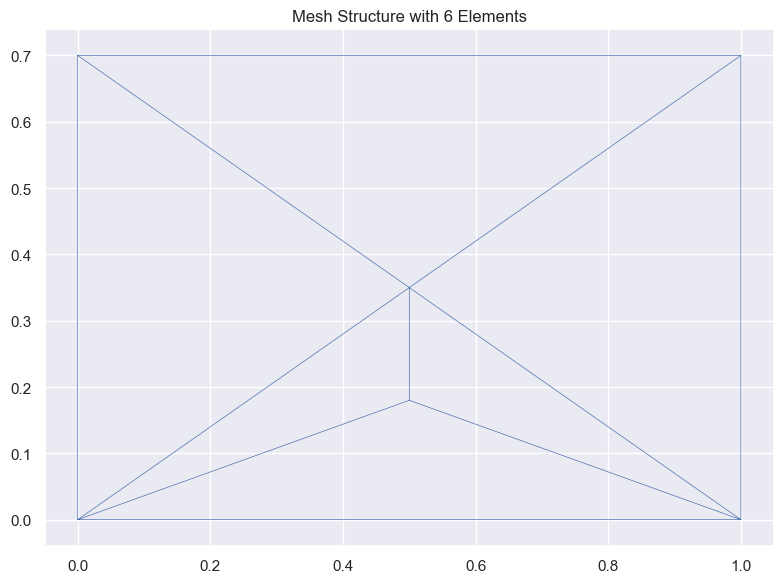

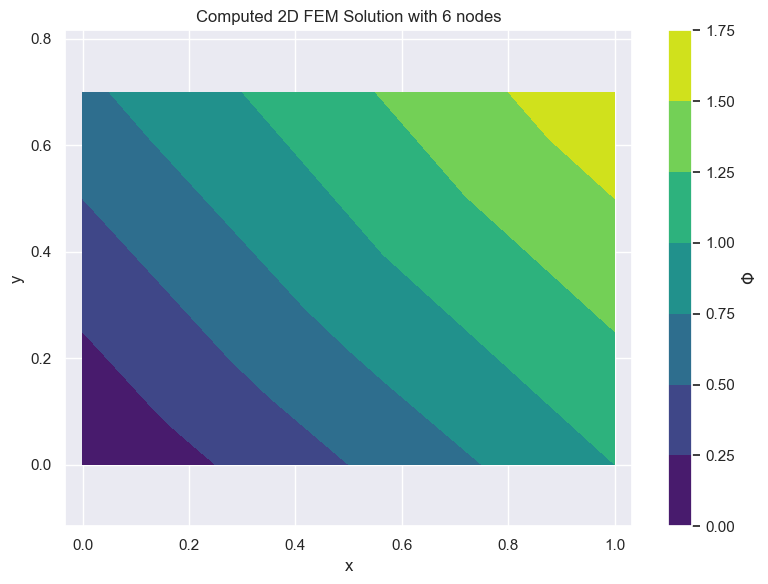

In [6]:
# solved with external functions
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)
reduced_maatrix, reduced_rhs = myfunc.insert_dirichlet_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, BOUNDARY_INDICES, boundary_func)
own_solution = myfunc.solve_system(DOMAIN_KNOTS, reduced_maatrix, reduced_rhs)
myfunc.plot_result(ELEMENTS, own_solution, levels=7)

## old solution

In [ ]:
def kronecker_delta(l, m):
    return 1 if l == m else 0

coefficients_matrix = np.zeros((6, 6))    # 6x6 matrix for coefficients
right_hand_side_matrix = np.zeros(6)    # 6x1 matrix for right-hand side

element_coefficients_matrix = np.zeros((3, 3))    # 3x3 matrix for coefficients

for i, element in enumerate(ELEMENTS):
    print(f"Element {i}: {element}")

    triangle_coordinates = [DOMAIN_KNOTS[element[0]], DOMAIN_KNOTS[element[1]], DOMAIN_KNOTS[element[2]]]    # [[x1, y1], [x2, y2], [x3, y3]]
    b = [triangle_coordinates[1][1] - triangle_coordinates[2][1], triangle_coordinates[2][1] - triangle_coordinates[0][1], triangle_coordinates[0][1] - triangle_coordinates[1][1]]

    c = [triangle_coordinates[2][0] - triangle_coordinates[1][0], triangle_coordinates[0][0] - triangle_coordinates[2][0], triangle_coordinates[1][0] - triangle_coordinates[0][0]]

    area_of_element = ( c[1] * b[0] - c[0] * b[1] ) / 2

    centroid = np.mean(triangle_coordinates, axis=0)    # x, y

    element_right_hand_side_matrix = area_of_element / 3 * rhs(*centroid)
    
    
    for l in range(3):
        for m in range(3):

            element_coefficients_matrix[l][m] = 1 / (4 *area_of_element) * (alpha1(*centroid) * b[l] * b[m] + alpha2(*centroid) * c[l] * c[m])
            element_coefficients_matrix[l][m] += area_of_element / 12 * beta(*centroid) * (1 + kronecker_delta(l,m)) 


    for l_local, l_global in enumerate(element):
        right_hand_side_matrix[l_global] += element_right_hand_side_matrix

        for m_local, m_global in enumerate(element):
            coefficients_matrix[l_global, m_global] += element_coefficients_matrix[l_local][m_local]




    print(b)
    print(c)
    print(f"Area of Element {i}: {area_of_element}")
    print(f"Centroid: {centroid}")
    print(element_coefficients_matrix)
    print(element_right_hand_side_matrix)

    print()
    print(coefficients_matrix)

print(right_hand_side_matrix)

Element 0: [0 4 1]
[np.float64(0.35), np.float64(-0.35), np.float64(0.0)]
[np.float64(0.5), np.float64(0.5), np.float64(-1.0)]
Area of Element 0: 0.175
Centroid: [0.5        0.58333333]
[[ 0.98467262  0.52529762 -1.48080357]
 [ 0.52529762  0.98467262 -1.48080357]
 [-1.48080357 -1.48080357  2.99077381]]
0.04901620370370371

[[ 0.98467262 -1.48080357  0.          0.          0.52529762  0.        ]
 [-1.48080357  2.99077381  0.          0.         -1.48080357  0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.52529762 -1.48080357  0.          0.          0.98467262  0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]]
Element 1: [3 1 4]
[np.float64(-0.35), np.float64(0.7), np.float64(-0.35)]
[np.float64(-0.5), np.float64(0.0), np.float64(0.5)]
Area of Element 1: 0.175
Centroid: [0.16666667 0.35      ]
[[ 0.72849537 -0.36960648 -0.35564815

## Incorporate the Dirichlet Issue

In [ ]:
# --- Evaluate boundary values at the boundary nodes ---
x_b = DOMAIN_KNOTS[BOUNDARY_INDICES][:, 0]
y_b = DOMAIN_KNOTS[BOUNDARY_INDICES][:, 1]
g_b = boundary_func(x_b, y_b)   # vector of boundary values

# --- Modify RHS before deleting rows/cols ---
# Subtract known boundary values from the RHS
# Loop over boundary nodes and subtract their contribution
right_hand_side_matrix_reduced = right_hand_side_matrix.copy()
for i, idx in enumerate(BOUNDARY_INDICES):
    right_hand_side_matrix_reduced -= coefficients_matrix[:, idx] * g_b[i]

# --- Remove rows and columns corresponding to Dirichlet BCs ---
coefficients_matrix = np.delete(coefficients_matrix, BOUNDARY_INDICES, axis=0)
coefficients_matrix = np.delete(coefficients_matrix, BOUNDARY_INDICES, axis=1)

right_hand_side_matrix_reduced = np.delete(right_hand_side_matrix_reduced, BOUNDARY_INDICES, axis=0)

print("Reduced Matrices:")
print(coefficients_matrix)
print(right_hand_side_matrix_reduced)

Reduced Matrices:
[[10.03199342 -5.73408442]
 [-5.73408442 10.84855664]]
[4.91093465 2.58114972]


## Solve the Linear Equations System

In [ ]:
reduced_solutions = np.linalg.solve(coefficients_matrix, right_hand_side_matrix_reduced) 

print(reduced_solutions)

[0.89630628 0.71167491]


## Add the Known Boundary Values

In [ ]:
result_indices = []
results = np.zeros(len(DOMAIN_KNOTS))

for index in BOUNDARY_INDICES:
    results[index] = boundary_func(*DOMAIN_KNOTS[index])
    result_indices.append(index)

result_indices = np.array(result_indices)
results = np.array(results).reshape(-1, 1)  # Ensure column shape

kept_indices = np.setdiff1d(np.arange(len(DOMAIN_KNOTS)), result_indices)

full_solution = np.full((len(DOMAIN_KNOTS), 1), np.nan)
full_solution[kept_indices] = reduced_solutions.reshape(-1, 1)
full_solution[result_indices] = results[result_indices].reshape(-1, 1)
 
print("Full Solution:")
print(full_solution)

Full Solution:
[[1.7       ]
 [0.89630628]
 [0.71167491]
 [0.        ]
 [0.7       ]
 [1.        ]]


## Plot the results

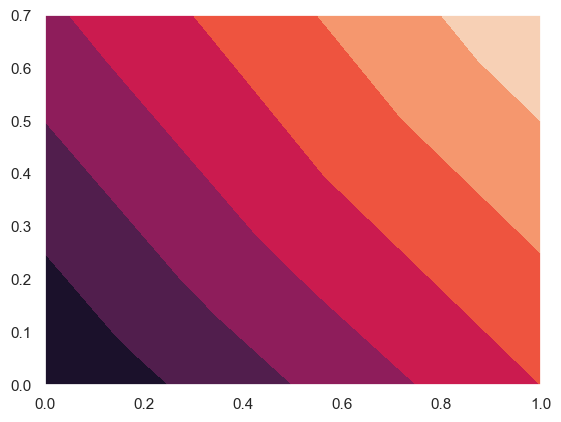

In [ ]:
plt.tricontourf(DOMAIN_KNOTS[:,0], DOMAIN_KNOTS[:,1], ELEMENTS, full_solution.flatten())